# Document Classification

## Objective

The goal of this notebook is to build the document classification component of our group project.

The system must classify documents into four categories:

- email
- invoice
- letter
- scientific_report

Because the dataset consists of `.tif` document images rather than plain text files, we first apply OCR to convert each image into machine-readable text. We then use classical text classification methods based on TF-IDF features.

This notebook builds:

1. a baseline classifier
2. an improved classifier
3. a comparison of results to justify the final model

In [1]:
from pathlib import Path

# --------------------------------------------------
# Project and dataset paths
# --------------------------------------------------
PROJECT_DIR = Path(r"D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork")
DATASET_DIR = PROJECT_DIR / "stat-data" / "stat-data" / "test"

CLASSES = ["email", "invoice", "letter", "scientific_report"]

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)

print("\nClass folders found:")
for class_name in CLASSES:
    print(f"{class_name}: {(DATASET_DIR / class_name).exists()}")

Project directory: D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork
Dataset directory: D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork\stat-data\stat-data\test

Class folders found:
email: True
invoice: True
letter: True
scientific_report: True


## Imports

We use:

- `Pillow` to open TIFF images
- `pytesseract` for OCR
- `pandas` for data handling
- `scikit-learn` for TF-IDF, training, and evaluation

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import pytesseract

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import FunctionTransformer, MaxAbsScaler

## OCR Setup

Before building the dataset, we configure Tesseract OCR and verify that it works on one sample invoice image.

In [3]:
# --------------------------------------------------
# Tesseract executable path
# --------------------------------------------------
TESSERACT_EXE = PROJECT_DIR / "tesseract" / "tesseract.exe"

print("Tesseract executable:", TESSERACT_EXE)
print("Exists:", TESSERACT_EXE.exists())

pytesseract.pytesseract.tesseract_cmd = str(TESSERACT_EXE)

Tesseract executable: D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork\tesseract\tesseract.exe
Exists: True


In [6]:
# Search for tesseract.exe if the exact path above is wrong
matches = list(PROJECT_DIR.rglob("tesseract.exe"))

print("Matches found:", len(matches))
for m in matches:
    print(m)

Matches found: 1
D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork\tesseract\tesseract.exe


In [8]:
# Quick OCR test on one invoice image
sample_image = next((DATASET_DIR / "invoice").glob("*.tif"))

print("Sample image:", sample_image)

img = Image.open(sample_image)
sample_text = pytesseract.image_to_string(img)

print("\nOCR preview:\n")
print(sample_text[:1500])

Sample image: D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork\stat-data\stat-data\test\invoice\0000023361.tif

OCR preview:

Sa teap”
»yBuakor a

3209308
1 7 Acmetede

sem goamayy apr

+ Leong wasatuaon

Moe owt 211 strowt
BSS SE UI asrevcny bo ot

ante




## OCR Validation

The OCR output is noisy, which is expected for scanned TIFF document images. However, it still captures enough document-specific textual patterns to support classification.

At this stage, the goal is not perfect transcription, but a usable text representation that allows classical machine learning models to distinguish between document categories.

In [11]:
def extract_text_from_tif(image_path: Path) -> str:
    """
    Extract text from a TIFF image using Tesseract OCR
    and apply light cleaning.
    """
    try:
        img = Image.open(image_path)
        text = pytesseract.image_to_string(img, lang="eng")
        text = text.replace("\n", " ")
        text = re.sub(r"\s+", " ", text).strip()
        return text
    except Exception as e:
        print(f"Error reading {image_path.name}: {e}")
        return ""

In [12]:
MAX_PER_CLASS = 300  # small subset first so the pipeline runs faster

rows = []

for label in CLASSES:
    image_paths = sorted((DATASET_DIR / label).glob("*.tif"))[:MAX_PER_CLASS]
    print(f"Processing {label} ({len(image_paths)} files)...")

    for image_path in image_paths:
        text = extract_text_from_tif(image_path)
        rows.append({
            "path": str(image_path),
            "label": label,
            "text": text
        })

df = pd.DataFrame(rows)

print("\nDataset shape:", df.shape)
df.head()

Processing email (300 files)...
Processing invoice (300 files)...
Processing letter (300 files)...
Processing scientific_report (300 files)...

Dataset shape: (1200, 3)


,path,label,text
0,D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8...,email,‘ Bd BROWN AND WILLIAMSON TOBACCO CORPORATION ...
1,D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8...,email,Author: Linda Carter at Ba C2 Date: 4/12/95 8:...
2,D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8...,email,BWINTERNAT LVL & A dabot cnsviink e29ua7bapor ...
3,D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8...,email,Author! Linde Certer at BL « De 5/25/98 4:25 F...
4,D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8...,email,ace oF oF oF 2ARD NATL OLD MESSAGE Om Route ou...


In [13]:
print(df["label"].value_counts())
print("\nEmpty OCR texts:", (df["text"].str.len() == 0).sum())

label
email                300
invoice              300
letter               300
scientific_report    300
Name: count, dtype: int64

Empty OCR texts: 13


In [14]:
df.to_csv(PROJECT_DIR / "ocr_subset_300_per_class.csv", index=False)
print("Saved.")

Saved.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 960
Test samples: 240


## Train-Test Split

We split the OCR-extracted dataset into training and testing sets while preserving class balance through stratification.

This allows us to evaluate how well the classifier generalizes to unseen documents.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 960
Test samples: 240


In [18]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_preds)

print("Baseline Accuracy:", baseline_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, baseline_preds))

Baseline Accuracy: 0.9083333333333333

Classification Report:

                   precision    recall  f1-score   support

            email       0.97      0.97      0.97        60
          invoice       0.87      0.88      0.88        60
           letter       0.90      0.87      0.88        60
scientific_report       0.90      0.92      0.91        60

         accuracy                           0.91       240
        macro avg       0.91      0.91      0.91       240
     weighted avg       0.91      0.91      0.91       240



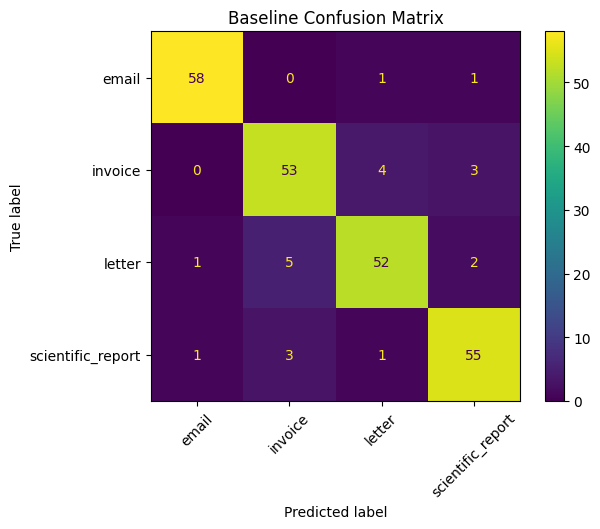

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, baseline_preds, xticks_rotation=45)
plt.title("Baseline Confusion Matrix")
plt.show()

## Advanced Classifier

For the advanced model, we improve the text representation by combining:

- word-level TF-IDF
- character-level TF-IDF

Character n-grams are especially useful in OCR-based document classification because they help capture partial words, formatting fragments, abbreviations, and OCR noise. The classifier used is a Linear Support Vector Machine, which is well suited to high-dimensional sparse text features.

In [20]:
advanced_features = FeatureUnion([
    ("word_tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=12000
    )),
    ("char_tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_features=8000
    ))
])

advanced_model = Pipeline([
    ("features", advanced_features),
    ("clf", LinearSVC(random_state=42))
])

advanced_model.fit(X_train, y_train)
advanced_preds = advanced_model.predict(X_test)

advanced_acc = accuracy_score(y_test, advanced_preds)

print("Advanced Accuracy:", advanced_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, advanced_preds))

Advanced Accuracy: 0.9041666666666667

Classification Report:

                   precision    recall  f1-score   support

            email       0.97      0.93      0.95        60
          invoice       0.89      0.92      0.90        60
           letter       0.91      0.83      0.87        60
scientific_report       0.86      0.93      0.90        60

         accuracy                           0.90       240
        macro avg       0.91      0.90      0.90       240
     weighted avg       0.91      0.90      0.90       240



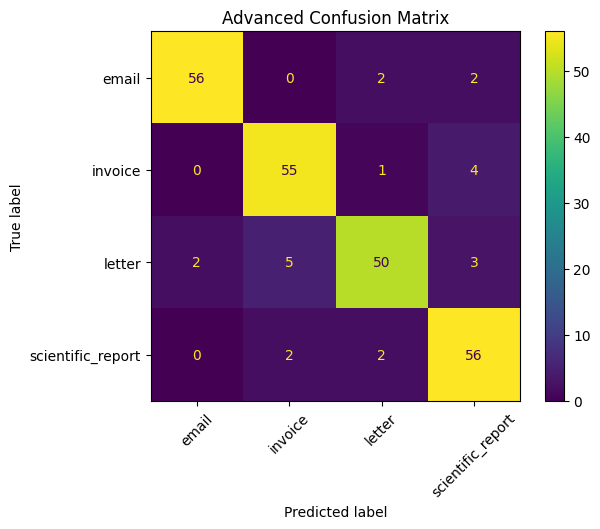

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, advanced_preds, xticks_rotation=45)
plt.title("Advanced Confusion Matrix")
plt.show()

## Model Comparison

We compare the baseline and advanced classifiers using overall accuracy in order to determine whether the richer text representation improves performance.

In [22]:
comparison_df = pd.DataFrame({
    "model": ["Baseline Logistic Regression", "Advanced Linear SVM"],
    "accuracy": [baseline_acc, advanced_acc]
})

comparison_df

,model,accuracy
0,Baseline Logistic Regression,0.908333
1,Advanced Linear SVM,0.904167


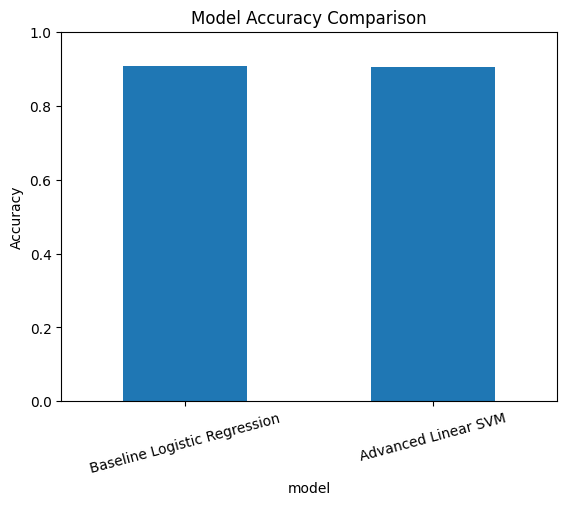

In [23]:
comparison_df.plot(kind="bar", x="model", y="accuracy", legend=False)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

## Tuned Advanced Classifier

As an additional experiment, we tune the Linear SVM based advanced classifier.

The goal is to test whether a different regularization strength improves performance on the OCR-based document classification task.

In [24]:
from sklearn.model_selection import GridSearchCV

tuned_pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_features=15000
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=10000
        ))
    ])),
    ("clf", LinearSVC(random_state=42))
])

param_grid = {
    "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0]
}

grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters: {'clf__C': 1.0}
Best cross-validation score: 0.9291666666666667


In [25]:
tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)

tuned_acc = accuracy_score(y_test, tuned_preds)

print("Tuned Advanced Accuracy:", tuned_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, tuned_preds))

Tuned Advanced Accuracy: 0.9041666666666667

Classification Report:

                   precision    recall  f1-score   support

            email       0.97      0.93      0.95        60
          invoice       0.89      0.92      0.90        60
           letter       0.91      0.83      0.87        60
scientific_report       0.86      0.93      0.90        60

         accuracy                           0.90       240
        macro avg       0.91      0.90      0.90       240
     weighted avg       0.91      0.90      0.90       240



In [26]:
comparison_df = pd.DataFrame({
    "model": [
        "Baseline Logistic Regression",
        "Advanced Linear SVM",
        "Tuned Advanced Linear SVM"
    ],
    "accuracy": [
        baseline_acc,
        advanced_acc,
        tuned_acc
    ]
})

comparison_df

,model,accuracy
0,Baseline Logistic Regression,0.908333
1,Advanced Linear SVM,0.904167
2,Tuned Advanced Linear SVM,0.904167


In [27]:
final_model = baseline_model

## Final Model Selection

Among the tested models, the baseline Logistic Regression classifier achieved the highest test accuracy on the OCR-based subset.

The advanced Linear SVM model and its tuned version produced very similar results, but did not outperform the baseline. Therefore, the final classification model selected for this project is the TF-IDF + Logistic Regression pipeline, as it offers the best trade-off between performance, simplicity, and interpretability.

In [30]:
from pathlib import Path

def predict_category(image_path: str) -> str:
    image_path = Path(image_path)
    text = extract_text_from_tif(image_path)
    prediction = final_model.predict([text])[0]
    return prediction

In [ ]:
test_image = next((DATASET_DIR / "invoice").glob("*.tif"))
print("Test image:", test_image)
print("Predicted class:", predict_category(str(test_image)))

Test image: D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork\stat-data\stat-data\test\invoice\0000023361.tif
Predicted class: invoice


In [38]:
import pickle

with open(PROJECT_DIR / "final_classifier.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Final classifier saved.")

Final classifier saved.


## Unseen Document Test

To further validate the classifier, we test it on documents that were not included in the OCR subset used for model development.

This gives a simple demonstration of how the system behaves on new inputs outside the experimental subset.

In [39]:
unseen_email = sorted((DATASET_DIR / "email").glob("*.tif"))[350]

print("Unseen test file:", unseen_email)
print("Predicted class:", predict_category(str(unseen_email)))

Unseen test file: D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork\stat-data\stat-data\test\email\2074196059a.tif
Predicted class: email


In [40]:
unseen_invoice = sorted((DATASET_DIR / "invoice").glob("*.tif"))[350]
unseen_letter = sorted((DATASET_DIR / "letter").glob("*.tif"))[350]
unseen_report = sorted((DATASET_DIR / "scientific_report").glob("*.tif"))[350]

print("Invoice prediction:", predict_category(str(unseen_invoice)))
print("Letter prediction:", predict_category(str(unseen_letter)))
print("Scientific report prediction:", predict_category(str(unseen_report)))

Invoice prediction: invoice
Letter prediction: letter
Scientific report prediction: scientific_report


## Final Model Selection

Three classification setups were tested on the OCR-based subset:

1. Baseline TF-IDF + Logistic Regression
2. Advanced TF-IDF (word + character n-grams) + Linear SVM
3. Tuned Linear SVM

Among these, the baseline Logistic Regression model achieved the highest test accuracy. Although the advanced models used a richer representation, they did not outperform the baseline on the current subset. For this reason, the final classifier selected for this project is the TF-IDF + Logistic Regression pipeline, as it offers the best trade-off between performance, simplicity, and interpretability.

In [41]:
final_model = baseline_model
print("Final model selected: Baseline Logistic Regression")

Final model selected: Baseline Logistic Regression


In [42]:
from pathlib import Path

def predict_category(image_path: str) -> str:
    """
    Predict the category of a document image by:
    1. extracting OCR text from the TIFF file
    2. applying the final classifier
    """
    image_path = Path(image_path)
    text = extract_text_from_tif(image_path)
    prediction = final_model.predict([text])[0]
    return prediction

## Unseen Document Demo

To validate the system beyond the experimental OCR subset, we test the final classifier on documents that were not included in the first 300 files per class used to build the working dataset.

This provides a simple end-to-end demonstration of how the classifier behaves on new inputs.

In [43]:
unseen_examples = {
    "email": sorted((DATASET_DIR / "email").glob("*.tif"))[350],
    "invoice": sorted((DATASET_DIR / "invoice").glob("*.tif"))[350],
    "letter": sorted((DATASET_DIR / "letter").glob("*.tif"))[350],
    "scientific_report": sorted((DATASET_DIR / "scientific_report").glob("*.tif"))[350],
}

for true_label, file_path in unseen_examples.items():
    predicted_label = predict_category(str(file_path))
    print(f"True: {true_label:18s} | Predicted: {predicted_label:18s} | File: {file_path.name}")

True: email              | Predicted: email              | File: 2074196059a.tif
True: invoice            | Predicted: invoice            | File: 03724910.tif
True: letter             | Predicted: letter             | File: 1000256234_1000256235.tif
True: scientific_report  | Predicted: scientific_report  | File: 1003225022_1003225065.tif


In [44]:
demo_rows = []

for true_label, file_path in unseen_examples.items():
    predicted_label = predict_category(str(file_path))
    demo_rows.append({
        "true_label": true_label,
        "predicted_label": predicted_label,
        "file_name": file_path.name
    })

demo_df = pd.DataFrame(demo_rows)
demo_df

,true_label,predicted_label,file_name
0,email,email,2074196059a.tif
1,invoice,invoice,03724910.tif
2,letter,letter,1000256234_1000256235.tif
3,scientific_report,scientific_report,1003225022_1003225065.tif


In [45]:
df.to_csv(PROJECT_DIR / "ocr_subset_300_per_class.csv", index=False)
print("Saved OCR subset to:", PROJECT_DIR / "ocr_subset_300_per_class.csv")

Saved OCR subset to: D:\MAIN\Academic\Y3S2\AISTATISTICALLEARNING\G8_GroupWork\ocr_subset_300_per_class.csv


The four selected document classes were email, invoice, letter, and scientific report. These categories were chosen because they are sufficiently distinct in structure and language while still being realistic in document-processing workflows. Emails tend to contain header-style fields such as sender, recipient, and subject lines. Invoices usually contain billing terminology, dates, totals, and issuer/recipient information. Letters often include greetings and sign-offs in a more formal narrative format. Scientific reports typically contain academic section markers such as abstract, introduction, and references. These differences make the classification task meaningful and technically justifiable.